<a href="https://colab.research.google.com/github/Sejal14-tech/auto_tagging/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelling


In [3]:
import numpy as np
import pandas as pd
import time
import ast
import torch
import os
import random
import transformers
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import hamming_loss, f1_score ,classification_report
from transformers import BertForSequenceClassification, BertTokenizer
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from google.colab import drive

start_time = time.time()
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
max = 30
path = '/content/drive/MyDrive/auto_tag/final_df.csv'
df = pd.read_csv(path)
# df['Target'] = df['Target'].apply(ast.literal_eval)
# df['Tag'] = df['Tag'].apply(ast.literal_eval)

# print(df.shape)
# display(df.head())

In [5]:
df['Target'] = df['Target'].apply(ast.literal_eval)
df['Tag'] = df['Tag'].apply(ast.literal_eval)

print(df.shape)
display(df.head())

(31524, 5)


,Text,Tag,Num_Tags,Num_Words,Target
0,"how to get the value of built, encoded viewsta...","[asp.net, c#]",2,120,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,convert hashbytes to varchar convert hashbytes...,"[sql, sql-server]",2,84,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,__tag_mysql__/apache error in __tag_php__ __ta...,"[mysql, php]",2,188,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ..."
3,the difference between a datagrid and a gridvi...,[asp.net],1,163,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,what are the useful new __tag_aspdotnet__ feat...,[asp.net],1,116,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [6]:
df

,Text,Tag,Num_Tags,Num_Words,Target
0,"how to get the value of built, encoded viewsta...","[asp.net, c#]",2,120,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,convert hashbytes to varchar convert hashbytes...,"[sql, sql-server]",2,84,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,__tag_mysql__/apache error in __tag_php__ __ta...,"[mysql, php]",2,188,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ..."
3,the difference between a datagrid and a gridvi...,[asp.net],1,163,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,what are the useful new __tag_aspdotnet__ feat...,[asp.net],1,116,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
31519,multiple checkboxes to show/hide divs multiple...,"[css, html, javascript, jquery]",4,160,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, ..."
31520,print n-th item print n-th item print n-th ite...,[python],1,159,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
31521,how to create a separated menu with logo in be...,"[css, html]",2,353,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, ..."
31522,why triggerhandler(event) gives me an error? w...,[angularjs],1,271,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:
unique_tags = set([tag for sublist in df['Tag'] for tag in sublist])

print(f"Number of Unique Tags: {len(unique_tags)}")
print(unique_tags)

Number of Unique Tags: 21
{'mysql', 'r', 'php', 'sql', 'jquery', 'git', 'html', 'c++', 'sql-server', 'c', 'ruby', 'c#', 'iphone', 'javascript', 'angularjs', 'asp.net', 'android', 'python', 'ruby-on-rails', 'java', 'css'}


In [8]:

def calculate_tag_combinations(temp_df):
    """
    Create a dataframe 'tag_combination', which stores the unique combination of Tags and the number of appearance
    """

    if temp_df.empty:
        print('Error: Provided DataFrame is empty!')
        return

    temp_df['Tag'] = temp_df['Tag'].apply(sorted)
    temp_df['Tag_Tuple'] = temp_df['Tag'].apply(tuple)
    tag_combinations = temp_df.groupby('Tag_Tuple').size().reset_index(name='Count')
    temp_df.drop(columns=['Tag_Tuple'], inplace=True)
    tag_combinations = tag_combinations.sort_values(by='Count', ascending=False)

    sum_count = tag_combinations['Count'].sum()
    all_tags = [tag for tag_tuple in tag_combinations['Tag_Tuple'] for tag in tag_tuple]
    num_unique_tags = len(set(all_tags))

    print(f"Number of Questions of Tag Combinations: {sum_count}")
    print(f"Number of unique tags of Tag Combinations: {num_unique_tags}")
    print(f"Minimum Frequency of Tag Combinations: {tag_combinations['Count'].iloc[-1]}\n")
    display(tag_combinations)

    return tag_combinations

original_tag_combinations = calculate_tag_combinations(df)

Number of Questions of Tag Combinations: 31524
Number of unique tags of Tag Combinations: 21
Minimum Frequency of Tag Combinations: 374



,Tag_Tuple,Count
0,"(android,)",3155
18,"(javascript, jquery)",2160
16,"(java,)",2021
17,"(javascript,)",2010
23,"(php,)",1756
19,"(jquery,)",1711
24,"(python,)",1642
7,"(c#,)",1619
10,"(css, html)",1391
8,"(c++,)",1325


In [9]:
def split_data(tag_combinations, df, create_val=True, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    # Shuffle the dataframe
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

    val_ratio = val_ratio if create_val else 0

    # Dicts to store counts for each combination
    train_counts = {combination: 0 for combination in tag_combinations['Tag_Tuple']}
    val_counts = {combination: 0 for combination in tag_combinations['Tag_Tuple']}
    test_counts = {combination: 0 for combination in tag_combinations['Tag_Tuple']}

    # Appropriate ratio of tag combinations for each set
    for index, row in tag_combinations.iterrows():
        combination = row['Tag_Tuple']
        count = row['Count']

        train_counts[combination] += int(count*train_ratio)
        val_counts[combination] += int(count*val_ratio)
        test_counts[combination] += count - int(count*train_ratio) - int(count*val_ratio)

    # Store data to list for each set
    train_data, val_data, test_data = [], [], []

    # Iterate over rows in df and assign to train, val, or test sets
    for index, row in df_shuffled.iterrows():
        combination = row['Tag']
        if train_counts[tuple(combination)] > 0:
            train_data.append(row)
            train_counts[tuple(combination)] -= 1
        elif test_counts[tuple(combination)] > 0:
            test_data.append(row)
            test_counts[tuple(combination)] -= 1
        elif val_counts[tuple(combination)] > 0:
            val_data.append(row)
            val_counts[tuple(combination)] -= 1

    assert len(train_data) + len(val_data) + len(test_data) == len(df), "Total number of examples in train, val, and test sets does not match the total number of examples in the original dataframe"
    return pd.DataFrame(train_data), pd.DataFrame(val_data), pd.DataFrame(test_data)

train_df, val_df, test_df = split_data(original_tag_combinations, df)


In [10]:
train_df['Tag'][0]

['c++']

In [11]:
train_df[train_df['Tag'].apply(lambda x: x == ['c++'])].shape

(1060, 5)

In [12]:
test_df[test_df['Tag'].apply(lambda x: x == ['c++'])].shape

(133, 5)

In [13]:
train_tag_combinations = calculate_tag_combinations(train_df)

Number of Questions of Tag Combinations: 25209
Number of unique tags of Tag Combinations: 21
Minimum Frequency of Tag Combinations: 299



,Tag_Tuple,Count
0,"(android,)",2524
18,"(javascript, jquery)",1728
16,"(java,)",1616
17,"(javascript,)",1608
23,"(php,)",1404
19,"(jquery,)",1368
24,"(python,)",1313
7,"(c#,)",1295
10,"(css, html)",1112
8,"(c++,)",1060


In [14]:
test_tag_combinations = calculate_tag_combinations(test_df)

Number of Questions of Tag Combinations: 3176
Number of unique tags of Tag Combinations: 21
Minimum Frequency of Tag Combinations: 38



,Tag_Tuple,Count
0,"(android,)",316
18,"(javascript, jquery)",216
16,"(java,)",203
17,"(javascript,)",201
23,"(php,)",177
19,"(jquery,)",172
24,"(python,)",165
7,"(c#,)",163
10,"(css, html)",140
8,"(c++,)",133


In [15]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [17]:
class BERTModel(torch.nn.Module):
    def __init__(self, num_labels, model_name):
        super(BERTModel, self).__init__()
        self.l1 = transformers.BertModel.from_pretrained(model_name, return_dict=False)
        self.l2 = torch.nn.Dropout(0.1)
        self.l3 = torch.nn.Linear(768, num_labels)

    def forward(self, ids, mask):
        _, output_1= self.l1(ids, attention_mask = mask)
        output_2 = self.l2(output_1)
        output = self.l3(output_2)
        return output

model = BERTModel(len(unique_tags),model_name)
model.to(device)

# Define model parameters and hyperparameters
max_length = 128
batch_size = 16
num_epochs = 3
learning_rate = 2e-5

# Define optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
X_train = train_df['Text'].fillna('').astype(str).tolist()
Y_train = train_df['Target'].tolist()
print('X_train Size:', len(X_train))
print('Y_train Size:', len(Y_train),'\n')

X_val = val_df['Text'].fillna('').astype(str).tolist()
Y_val = val_df['Target'].tolist()
print('X_val Size:', len(X_val))
print('Y_val Size:', len(Y_val),'\n')

X_test = test_df['Text'].fillna('').astype(str).tolist()
Y_test = test_df['Target'].tolist()
print('X_test Size:', len(X_test))
print('Y_test Size:', len(Y_test))

X_train Size: 25209
Y_train Size: 25209 

X_val Size: 3139
Y_val Size: 3139 

X_test Size: 3176
Y_test Size: 3176


In [28]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])  # Explicitly cast to string
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].squeeze(), 'attention_mask': encoding['attention_mask'].squeeze(), 'labels': torch.tensor(label)}

train_dataset = CustomDataset(X_train, Y_train, tokenizer, max_length)
valid_dataset = CustomDataset(X_val, Y_val, tokenizer, max_length)
test_dataset = CustomDataset(X_test, Y_test, tokenizer, max_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [21]:
def display_info(temp_loader,name):
    first_batch_train = next(iter(temp_loader))
    input_ids_shape_train = first_batch_train['input_ids'].shape
    attention_mask_shape_train = first_batch_train['attention_mask'].shape
    labels_shape_train = first_batch_train['labels'].shape
    print(name, "Loader First Batch Shapes:")
    print("Input IDs Shape:", input_ids_shape_train)
    print("Attention Mask Shape:", attention_mask_shape_train)
    print("Labels Shape:", labels_shape_train)
    print("Number of Batches:", len(temp_loader),'\n')

display_info(train_loader,'Train')
display_info(valid_loader,'Valid')
display_info(test_loader,'Test')

Train Loader First Batch Shapes:
Input IDs Shape: torch.Size([16, 128])
Attention Mask Shape: torch.Size([16, 128])
Labels Shape: torch.Size([16, 21])
Number of Batches: 1576 

Valid Loader First Batch Shapes:
Input IDs Shape: torch.Size([16, 128])
Attention Mask Shape: torch.Size([16, 128])
Labels Shape: torch.Size([16, 21])
Number of Batches: 197 

Test Loader First Batch Shapes:
Input IDs Shape: torch.Size([16, 128])
Attention Mask Shape: torch.Size([16, 128])
Labels Shape: torch.Size([16, 21])
Number of Batches: 199 



In [23]:
vocab_size = tokenizer.vocab_size
print("Vocabulary size:", vocab_size)

max_tokens = tokenizer.model_max_length
print("Maximum number of tokens:", max_tokens)

Vocabulary size: 30522
Maximum number of tokens: 512


In [24]:
# Iterate over batches in train_loader
for batch_idx, batch in enumerate(train_loader):
    # Get inputs and labels from batch
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    # Print 3 samples
    print(f"Batch {batch_idx + 1}:")
    for i in range(min(3, len(input_ids))):
        print(f"Sample {i + 1}:")
        print("Input IDs:", input_ids[i])
        print("Attention Mask:", attention_mask[i])
        print("Labels:", labels[i])
        print()
        print()
    break

Batch 1:
Sample 1:
Input IDs: tensor([  101,  3091,  3200,  5651,  1000,  6151, 28344,  1000,  3091,  3200,
         5651,  1000,  6151, 28344,  1000,  3091,  3200,  5651,  1000,  6151,
        28344,  1000,  1045,  2031,  1037,  3291,  2007,  3091,  3200,  4192,
         1000,  6151, 28344,  1000,  2044,  2008,  1045,  2031,  2517,  2026,
         3642,  1012,  2026,  4708,  2003,  2893,  3091,  1997,  1996,  3793,
         1012,  1045,  2031,  2699,  2041,  2000,  2079,  2009,  1010,  2021,
         2009,  2515,  2025,  2147,  1012,  2292,  2149,  2298,  2012,  2026,
         3642,  1998,  2424,  2019,  7561,  1012,  1026,  1044,  2487,  8909,
         1027,  1000,  1056,  1000,  1028, 23746,  1026,  1013,  1044,  2487,
         1028,  1026,  7953,  2828,  1027,  1000, 12040,  1000,  3643,  1027,
         1000,  1053,  1000,  2006, 20464,  6799,  1027,  1000,  5342,  1006,
         1007,  1000,  1028,  1026,  5896,  1028,  3853,  5342,  1006,  1007,
         1063, 13075,  1053,  4160

In [29]:
training_init = time.time()

########################
#### Training Stage ####
########################
train_losses = []
val_losses = []

model.train()
for epoch in range(num_epochs):
    train_iterator = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', total=len(train_loader), unit='batch')
    epoch_init = time.time()
    epoch_train_loss = 0.0

    for batch_idx, batch in enumerate(train_iterator, 1):
        train_iterator.set_description(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}')

        input_ids = batch['input_ids'].to(device, dtype = torch.long)
        attention_mask = batch['attention_mask'].to(device, dtype = torch.long)
        labels = batch['labels'].to(device, dtype = torch.float)

        optimizer.zero_grad()
        outputs = model.forward(input_ids, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    train_losses.append(epoch_train_loss / len(train_loader))

    ##########################
    #### Validation Stage ####
    ##########################
    epoch_val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for batch in valid_loader:
            input_ids = batch['input_ids'].to(device, dtype = torch.long)
            attention_mask = batch['attention_mask'].to(device, dtype = torch.long)
            labels = batch['labels'].to(device, dtype = torch.float)

            outputs = model.forward(input_ids, attention_mask)

            preds = torch.sigmoid(outputs).cpu().numpy()
            preds[preds >= 0.5] = 1
            preds[preds < 0.5] = 0

            epoch_val_loss += loss.item()

    val_losses.append(epoch_val_loss / len(valid_loader))
    print(f"Epoch {epoch+1}/{num_epochs}, Epoch Duration: {int((time.time() - epoch_init) / 60)} minutes, Train Loss: {round(train_losses[-1],2)}, Val Loss: {round(val_losses[-1],2)}\n")

print("\nTraining Duration:", int((time.time()-training_init)/60), "minutes")

Epoch 1/3, Batch 1576/1576: 100%|██████████| 1576/1576 [10:19<00:00,  2.54batch/s]


Epoch 1/3, Epoch Duration: 10 minutes, Train Loss: 0.07, Val Loss: 0.1



Epoch 2/3, Batch 1576/1576: 100%|██████████| 1576/1576 [10:11<00:00,  2.58batch/s]


Epoch 2/3, Epoch Duration: 10 minutes, Train Loss: 0.05, Val Loss: 0.05



Epoch 3/3, Batch 1576/1576: 100%|██████████| 1576/1576 [10:12<00:00,  2.57batch/s]


Epoch 3/3, Epoch Duration: 10 minutes, Train Loss: 0.04, Val Loss: 0.03


Training Duration: 32 minutes


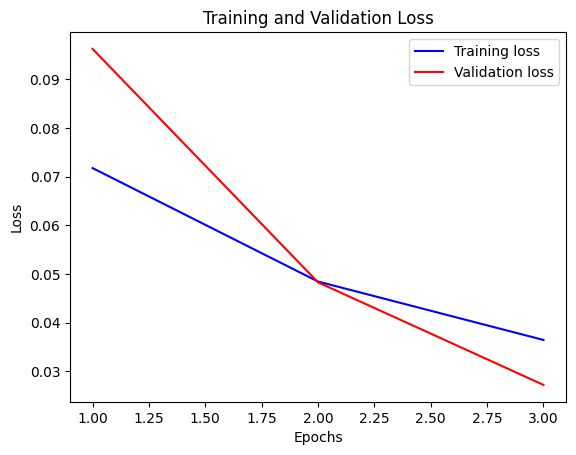

In [30]:
epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, 'b', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [31]:

##########################
#### Evaluation Stage ####
##########################
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device, dtype = torch.long)
        attention_mask = batch['attention_mask'].to(device, dtype = torch.long)
        labels = batch['labels'].to(device, dtype = torch.float)

        outputs = model.forward(input_ids, attention_mask)

        preds = torch.sigmoid(outputs).cpu().numpy()
        preds[preds >= 0.5] = 1
        preds[preds < 0.5] = 0

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

In [32]:
# Convert predictions and labels to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute evaluation metrics
hamming_loss_val = round(hamming_loss(all_labels, all_preds),2)
micro_f1 = round(f1_score(all_labels, all_preds, average='micro'),2)
macro_f1 = round(f1_score(all_labels, all_preds, average='macro'),2)

print(f"Hamming Loss: {hamming_loss_val}\tMicro-F1: {micro_f1}\t\tMacro-F1: {macro_f1}")

Hamming Loss: 0.02	Micro-F1: 0.83		Macro-F1: 0.84


In [33]:

mlb = MultiLabelBinarizer()
tag_matrix = mlb.fit_transform(test_df['Tag'].tolist())

In [34]:

print('*'*60)
for i in range(len(Y_train[0])):
    print(mlb.classes_[i])
    print(classification_report(all_labels[:,i], all_preds[:,i]),'\n'+'*'*60)

************************************************************
android
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      2793
         1.0       0.98      0.90      0.94       383

    accuracy                           0.99      3176
   macro avg       0.98      0.95      0.97      3176
weighted avg       0.99      0.99      0.99      3176
 
************************************************************
angularjs
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3081
         1.0       0.97      1.00      0.98        95

    accuracy                           1.00      3176
   macro avg       0.98      1.00      0.99      3176
weighted avg       1.00      1.00      1.00      3176
 
************************************************************
asp.net
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3062
         1.0       0.83   

In [35]:

print("Total time to run the notebook:", int((time.time()-start_time)/60), "minutes")

Total time to run the notebook: 55 minutes
